## Import Semua Packages/Library yang Digunakan

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import random
from PIL import Image
import shutil
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Colab: {IN_COLAB}")

Running in Colab: True


In [3]:
import tensorflow as tf

# Mengecek daftar physical devices yang tersedia
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"GPU Terdeteksi: {gpu_devices}")
    print("Model Anda akan berjalan menggunakan akselerasi GPU.")
else:
    print("GPU TIDAK terdeteksi. Notebook masih berjalan menggunakan CPU.")
    print("Jika di Colab, aktifkan via: Edit > Notebook settings > T4 GPU.")

GPU Terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Model Anda akan berjalan menggunakan akselerasi GPU.


## Data Preparation

### Data Loading

In [4]:
# Lokasi folder train
import kagglehub


path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")
print("Path to dataset files:", path)


100%|██████████| 534M/534M [00:13<00:00, 41.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/misrakahmed/vegetable-image-dataset/versions/1


In [5]:
# Path folder TRAIN
base_path = os.path.join(path, "Vegetable Images", "train")

print("Isi folder train:", os.listdir(base_path))
for cls in sorted(os.listdir(base_path)):
    n_images = len(os.listdir(os.path.join(base_path, cls)))
    print(f"{cls:15s}: {n_images} images")


Isi folder train: ['Capsicum', 'Bottle_Gourd', 'Tomato', 'Broccoli', 'Carrot', 'Bean', 'Bitter_Gourd', 'Cabbage', 'Potato', 'Brinjal', 'Cucumber', 'Radish', 'Pumpkin', 'Papaya', 'Cauliflower']
Bean           : 1000 images
Bitter_Gourd   : 1000 images
Bottle_Gourd   : 1000 images
Brinjal        : 1000 images
Broccoli       : 1000 images
Cabbage        : 1000 images
Capsicum       : 1000 images
Carrot         : 1000 images
Cauliflower    : 1000 images
Cucumber       : 1000 images
Papaya         : 1000 images
Potato         : 1000 images
Pumpkin        : 1000 images
Radish         : 1000 images
Tomato         : 1000 images


In [6]:
#Cek resolusi gambar
def print_images_resolution(directory):
    total_images = 0
    all_sizes = set()

    for subdir in sorted(os.listdir(directory)):
        subdir_path = os.path.join(directory, subdir)
        if not os.path.isdir(subdir_path):
            continue

        image_files = [
            f for f in os.listdir(subdir_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        print(f"{subdir}: {len(image_files)}")
        total_images += len(image_files)

        unique_sizes = set()
        for img_file in image_files:
            img_path = os.path.join(subdir_path, img_file)
            with Image.open(img_path) as img:
                unique_sizes.add(img.size)
                all_sizes.add(img.size)

        print("Ukuran unik:")
        for size in sorted(unique_sizes):
            print(f"- {size}")
        print("---------------")

    print(f"\nTotal: {total_images}")
    print(f"Total ukuran unik dataset: {len(all_sizes)}")

print_images_resolution(base_path)

Bean: 1000
Ukuran unik:
- (224, 224)
---------------
Bitter_Gourd: 1000
Ukuran unik:
- (224, 193)
- (224, 200)
- (224, 205)
- (224, 224)
---------------
Bottle_Gourd: 1000
Ukuran unik:
- (224, 224)
---------------
Brinjal: 1000
Ukuran unik:
- (224, 224)
---------------
Broccoli: 1000
Ukuran unik:
- (224, 224)
---------------
Cabbage: 1000
Ukuran unik:
- (224, 224)
---------------
Capsicum: 1000
Ukuran unik:
- (224, 224)
---------------
Carrot: 1000
Ukuran unik:
- (224, 224)
---------------
Cauliflower: 1000
Ukuran unik:
- (224, 224)
---------------
Cucumber: 1000
Ukuran unik:
- (224, 224)
---------------
Papaya: 1000
Ukuran unik:
- (224, 198)
- (224, 210)
- (224, 211)
- (224, 224)
---------------
Potato: 1000
Ukuran unik:
- (224, 224)
---------------
Pumpkin: 1000
Ukuran unik:
- (224, 224)
---------------
Radish: 1000
Ukuran unik:
- (224, 224)
---------------
Tomato: 1000
Ukuran unik:
- (224, 224)
---------------

Total: 15000
Total ukuran unik dataset: 7


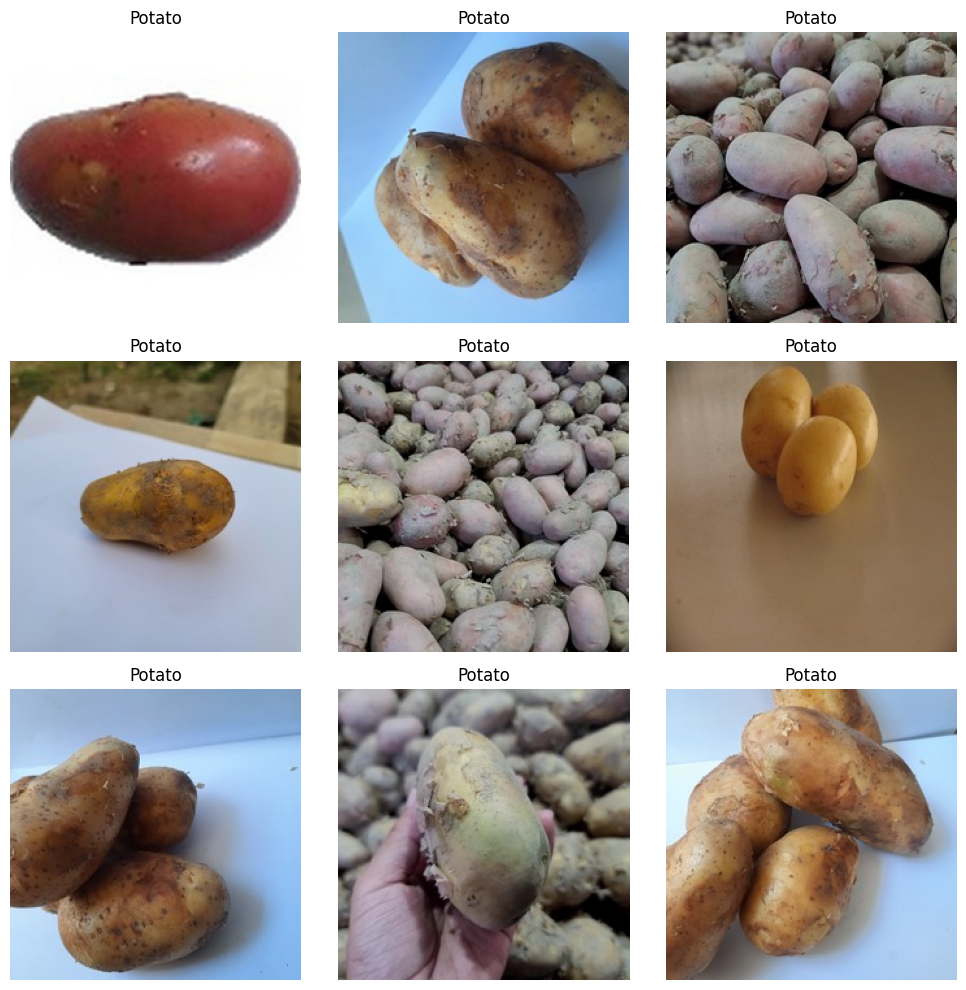

In [7]:
# Pilih kelas secara acak
sample_class = random.choice(os.listdir(base_path))

# Ambil sampai 9 gambar dari kelas tersebut
sample_files = os.listdir(os.path.join(base_path, sample_class))
sample_files = [f for f in sample_files if f.lower().endswith((".jpg", ".jpeg", ".png"))]

# Pastikan jumlah minimal
sample_files = sample_files[:9]

# Tampilkan
plt.figure(figsize=(10,10))
for i, fname in enumerate(sample_files):
    img_path = os.path.join(base_path, sample_class, fname)
    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(sample_class)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Data Preprocessing

#### Split Dataset

In [8]:
# Folder dataset bawaan
train_path = os.path.join(path, "Vegetable Images", "train")
val_path   = os.path.join(path, "Vegetable Images", "validation")
test_path  = os.path.join(path, "Vegetable Images", "test")

original_train = train_path
print("Dataset path split bawaan siap digunakan!")


Dataset path split bawaan siap digunakan!


In [9]:
def count_images(path):
    total = 0
    for cls in os.listdir(path):
        cls_folder = os.path.join(path, cls)
        if os.path.isdir(cls_folder):
            total += len(os.listdir(cls_folder))
    return total

train_count = count_images(train_path)
val_count   = count_images(val_path)
test_count  = count_images(test_path)

num_classes = len(os.listdir(original_train))

print("Jumlah kelas:", num_classes)
print("Jumlah gambar training  :", train_count)
print("Jumlah gambar validation:", val_count)
print("Jumlah gambar testing   :", test_count)

print("\nDaftar kelas:")
for cls in sorted(os.listdir(original_train)):
    print("-", cls)


Jumlah kelas: 15
Jumlah gambar training  : 15000
Jumlah gambar validation: 3000
Jumlah gambar testing   : 3000

Daftar kelas:
- Bean
- Bitter_Gourd
- Bottle_Gourd
- Brinjal
- Broccoli
- Cabbage
- Capsicum
- Carrot
- Cauliflower
- Cucumber
- Papaya
- Potato
- Pumpkin
- Radish
- Tomato


In [10]:
# Ukuran input gambar
img_size = (224, 224)
batch_size = 32

# Data Augmentation hanya pada data train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode="nearest"
)

# VALIDATION & TEST
val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Membuat Generator
train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_gen = val_datagen.flow_from_directory(
    val_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Tampilkan kelas
print("Class indices:", train_gen.class_indices)
num_classes = train_gen.num_classes


Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Class indices: {'Bean': 0, 'Bitter_Gourd': 1, 'Bottle_Gourd': 2, 'Brinjal': 3, 'Broccoli': 4, 'Cabbage': 5, 'Capsicum': 6, 'Carrot': 7, 'Cauliflower': 8, 'Cucumber': 9, 'Papaya': 10, 'Potato': 11, 'Pumpkin': 12, 'Radish': 13, 'Tomato': 14}


## Modelling

In [11]:
model = keras.Sequential([
    # Input Layer
    layers.InputLayer(input_shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Block 4
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten & Dense
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,686,223 (36.95 MB)

 Trainable params: 9,686,223 (36.95 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [13]:
epochs = 25

history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=val_gen,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 240s 490ms/step - accuracy: 0.4374 - loss: 1.6353 - val_accuracy: 0.7163 - val_loss: 0.8618 - learning_rate: 0.0010
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 232s 495ms/step - accuracy: 0.7031 - loss: 0.8922 - val_accuracy: 0.8443 - val_loss: 0.4707 - learning_rate: 0.0010
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 222s 473ms/step - accuracy: 0.7909 - loss: 0.6411 - val_accuracy: 0.8747 - val_loss: 0.4090 - learning_rate: 0.0010
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 221s 472ms/step - accuracy: 0.8299 - loss: 0.5167 - val_accuracy: 0.9217 - val_loss: 0.2524 - learning_rate: 0.0010
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 222s 472ms/step - accuracy: 0.8597 - loss: 0.4352 - val_accuracy: 0.9353 - val_loss: 0.1962 - learning_rate: 0.0010
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 223s 475ms/step - accuracy: 0.8762 - loss: 0.3873 - val_accuracy: 0.9387 - val_loss: 0.2013 - learning_rate: 0.0010
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 222s 474ms/step - accura

## Evaluasi dan Visualisasi

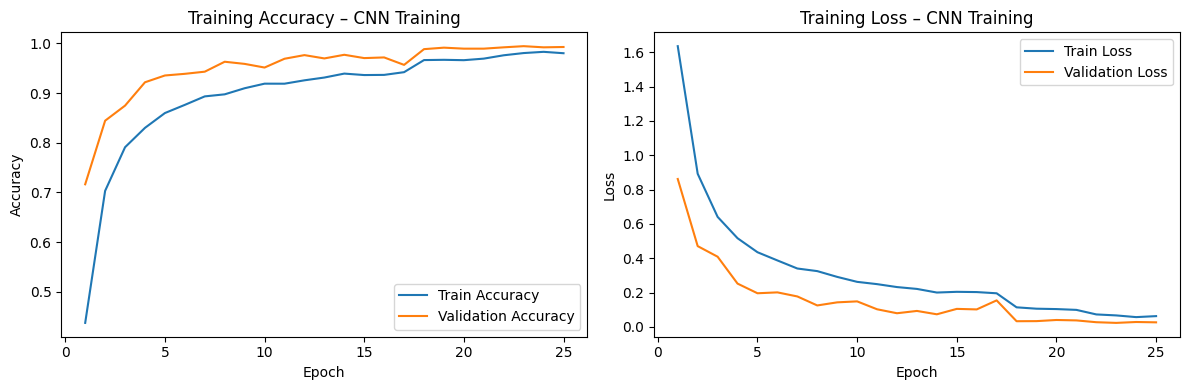

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9917 - loss: 0.0311

Test Accuracy : 0.9917
Test Loss     : 0.0311
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step


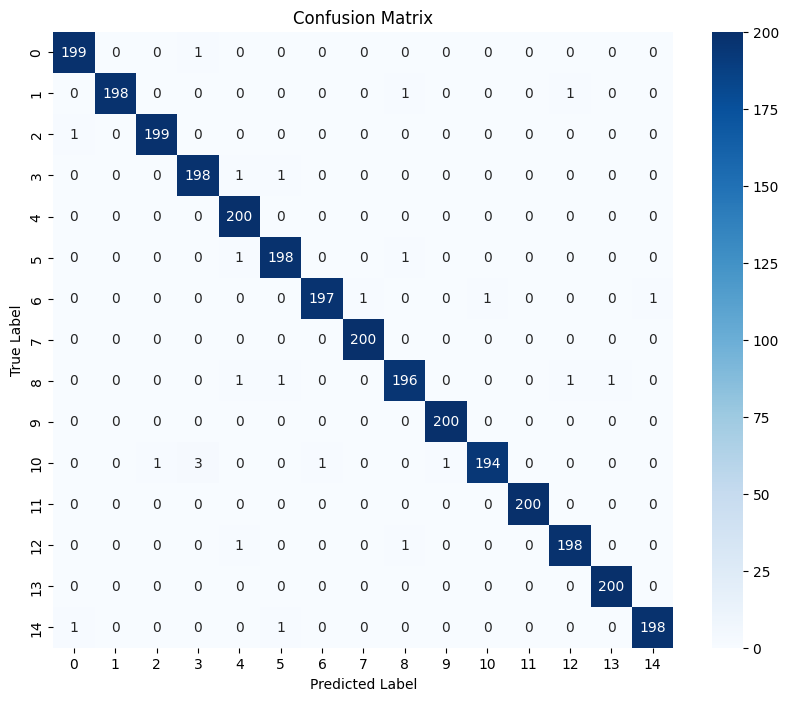


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Bean       0.99      0.99      0.99       200
Bitter_Gourd       1.00      0.99      0.99       200
Bottle_Gourd       0.99      0.99      0.99       200
     Brinjal       0.98      0.99      0.99       200
    Broccoli       0.98      1.00      0.99       200
     Cabbage       0.99      0.99      0.99       200
    Capsicum       0.99      0.98      0.99       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       0.98      0.98      0.98       200
    Cucumber       1.00      1.00      1.00       200
      Papaya       0.99      0.97      0.98       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       0.99      0.99      0.99       200
      Radish       1.00      1.00      1.00       200
      Tomato       0.99      0.99      0.99       200

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
we

In [14]:
# FUNGSI PLOT HISTORY
def plot_history(hist, title_suffix=""):
    acc      = hist.history['accuracy']
    val_acc  = hist.history.get('val_accuracy', None)
    loss     = hist.history['loss']
    val_loss = hist.history.get('val_loss', None)

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Accuracy")
    if val_acc is not None:
        plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(f"Training Accuracy {title_suffix}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Train Loss")
    if val_loss is not None:
        plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(f"Training Loss {title_suffix}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# PLOT TRAINING
plot_history(history, "– CNN Training")

# EVALUASI PADA TEST SET
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

# CONFUSION MATRIX & REPORT

# Label asli dan prediksi
y_true = test_gen.classes
y_prob = model.predict(test_gen)
y_pred = np.argmax(y_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report
print("\nCLASSIFICATION REPORT:")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_gen.class_indices.keys())
))


## Konversi Model

In [16]:
base_dir = "submission"

os.makedirs(f"{base_dir}/saved_model", exist_ok=True)
os.makedirs(f"{base_dir}/tflite", exist_ok=True)
os.makedirs(f"{base_dir}/tfjs_model", exist_ok=True)

# SAVE MODEL → SavedModel
saved_model_path = f"{base_dir}/saved_model"
model.export(saved_model_path)
print("✔ SavedModel berhasil dibuat!")

# SAVE MODEL → TFLITE
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
tflite_model = converter.convert()

with open(f"{base_dir}/tflite/model.tflite", "wb") as f:
    f.write(tflite_model)

print("✔ TFLite model berhasil dibuat!")


# SAVE LABELS
labels = list(train_gen.class_indices.keys())
with open(f"{base_dir}/tflite/label.txt", "w") as f:
    f.write("\n".join(labels))

print("✔ label.txt berhasil dibuat!")


Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  139823657898000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823657899728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823657901072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823657899344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823657899152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823657901264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823657902032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823657900496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823657902224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139823657902992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1398236

In [17]:
shutil.make_archive("submission", "zip", "submission")


'/content/submission.zip'

In [18]:
files.download("submission.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.2
aiohttp==3.14.1
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.0
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.6.8.17.49.5
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.7.2
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.42.0
bigquery-magics==0.14.0
bleach==6.4.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.4.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.47
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.5.20
cf

## Inference (Optional)

✔ SavedModel loaded (TF runtime mode)
❌ File 'tomatoo.jpg' tidak ditemukan.
Silakan unggah gambar yang ingin diprediksi:


Saving tomat.jpg to tomat.jpg
✔ Menggunakan file: tomat.jpg
Hasil Inferensi:
Prediksi index : 14
Prediksi label : Tomato
Confidence     : 1.0


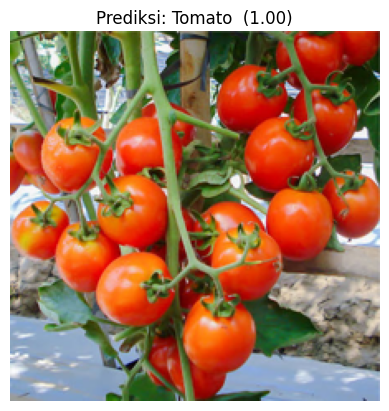

In [29]:
# LOAD SavedModel
loaded = tf.saved_model.load("submission/saved_model")
infer = loaded.signatures["serving_default"]
print("✔ SavedModel loaded (TF runtime mode)")

# Fungsi preprocessing
def load_image(path, img_size=(224, 224)):
    img = Image.open(path).convert("RGB")
    img = img.resize(img_size)
    arr = np.array(img) / 255.0
    arr = np.expand_dims(arr, 0)
    return img, arr.astype(np.float32)

# Pastikan file gambar ada atau minta upload
image_path = "tomatoo.jpg"

if not os.path.exists(image_path):
    print(f"❌ File '{image_path}' tidak ditemukan.")
    print("Silakan unggah gambar yang ingin diprediksi:")
    uploaded = files.upload()
    if uploaded:
        image_path = list(uploaded.keys())[0]
        print(f"✔ Menggunakan file: {image_path}")

if os.path.exists(image_path):
    # LOAD gambar
    img_show, img_input = load_image(image_path)

    # Konversi ke tensor
    input_tensor = tf.convert_to_tensor(img_input)

    # INFERENCE
    output = infer(input_tensor)
    pred = list(output.values())[0].numpy()
    pred_idx = np.argmax(pred)

    # LABEL
    labels = list(train_gen.class_indices.keys())

    print("===================================")
    print("Hasil Inferensi:")
    print("Prediksi index :", pred_idx)
    print("Prediksi label :", labels[pred_idx])
    print("Confidence     :", float(np.max(pred)))
    print("===================================")

    plt.imshow(img_show)
    plt.title(f"Prediksi: {labels[pred_idx]}  ({np.max(pred):.2f})")
    plt.axis("off")
    plt.show()
else:
    print("Gagal melakukan inferensi karena gambar tidak tersedia.")

✔ SavedModel loaded (TF runtime mode)
❌ File 'carot.jpg' tidak ditemukan.
Silakan unggah gambar (misal: wortel atau tomat) untuk diprediksi:


Saving wortel.jpg to wortel.jpg
✔ Menggunakan file: wortel.jpg
Hasil Inferensi:
Prediksi index : 7
Prediksi label : Carrot
Confidence     : 0.9796738028526306


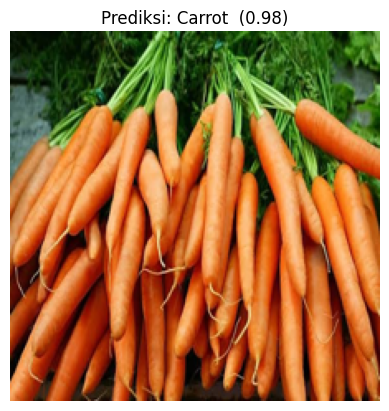

In [27]:
# LOAD SavedModel
loaded = tf.saved_model.load("submission/saved_model")
infer = loaded.signatures["serving_default"]
print("✔ SavedModel loaded (TF runtime mode)")

# Fungsi preprocessing
def load_image(path, img_size=(224, 224)):
    img = Image.open(path).convert("RGB")
    img = img.resize(img_size)
    arr = np.array(img) / 255.0
    arr = np.expand_dims(arr, 0)
    return img, arr.astype(np.float32)

# Pastikan file gambar ada atau minta upload
image_path = "carot.jpg"

if not os.path.exists(image_path):
    print(f"❌ File '{image_path}' tidak ditemukan.")
    print("Silakan unggah gambar (misal: wortel atau tomat) untuk diprediksi:")
    uploaded = files.upload()
    if uploaded:
        image_path = list(uploaded.keys())[0]
        print(f"✔ Menggunakan file: {image_path}")

if os.path.exists(image_path):
    # LOAD gambar
    img_show, img_input = load_image(image_path)

    # Konversi ke tensor
    input_tensor = tf.convert_to_tensor(img_input)

    # INFERENCE
    output = infer(input_tensor)
    pred = list(output.values())[0].numpy()
    pred_idx = np.argmax(pred)

    # LABEL
    labels = list(train_gen.class_indices.keys())

    print("===================================")
    print("Hasil Inferensi:")
    print("Prediksi index :", pred_idx)
    print("Prediksi label :", labels[pred_idx])
    print("Confidence     :", float(np.max(pred)))
    print("===================================")

    plt.imshow(img_show)
    plt.title(f"Prediksi: {labels[pred_idx]}  ({np.max(pred):.2f})")
    plt.axis("off")
    plt.show()
else:
    print("Gagal melakukan inferensi karena gambar tidak tersedia.")